## Introducción

En este proyecto se analiza el comportamiento de los usuarios dentro de una aplicación de productos alimenticios con el objetivo de comprender qué tan eficiente es el recorrido desde la primera interacción hasta la compra. Para ello, primero se estudia el embudo de eventos para identificar en qué etapas los usuarios avanzan y en cuáles abandonan el proceso.

Posteriormente, se analizan los resultados de un experimento A/A/B realizado por el equipo de producto. El objetivo del experimento es evaluar si un cambio en la tipografía de la aplicación afecta el comportamiento de los usuarios durante su navegación. Para reducir el riesgo de interpretaciones incorrectas, el experimento incluye dos grupos de control con el diseño actual y un grupo de prueba con la nueva tipografía.

El dataset contiene registros de eventos generados por los usuarios dentro de la aplicación. Cada fila representa una acción realizada por un usuario específico en un momento determinado. Estos registros permiten reconstruir el recorrido de los usuarios dentro de la aplicación y evaluar tanto el embudo de conversión como los resultados del experimento.

**Descripción de las variables**

- EventName
Indica la acción que el usuario realizó dentro de la aplicación. Generalmente corresponde a la visualización de una pantalla o a un paso dentro del proceso de compra.

Ejemplos de eventos registrados en el dataset:

- MainScreenAppear

- OffersScreenAppear

- CartScreenAppear

- PaymentScreenSuccessful

- Tutorial

Estos eventos representan las distintas etapas de interacción del usuario con la aplicación. A partir de ellos es posible reconstruir el flujo de navegación y analizar el recorrido que realizan los usuarios hasta completar una compra.


## Paso 1. Abrir el archivo de datos y leer la información general

In [1]:
import pandas as pd

logs = pd.read_csv('/datasets/logs_exp_us.csv')

logs.head()


,EventName\tDeviceIDHash\tEventTimestamp\tExpId
0,MainScreenAppear\t4575588528974610257\t1564029...
1,MainScreenAppear\t7416695313311560658\t1564053...
2,PaymentScreenSuccessful\t3518123091307005509\t...
3,CartScreenAppear\t3518123091307005509\t1564054...
4,PaymentScreenSuccessful\t6217807653094995999\t...


In [2]:
logs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 1 columns):
 #   Column                                       Non-Null Count   Dtype 
---  ------                                       --------------   ----- 
 0   EventName	DeviceIDHash	EventTimestamp	ExpId  244126 non-null  object
dtypes: object(1)
memory usage: 1.9+ MB


In [3]:
logs.describe()

,EventName\tDeviceIDHash\tEventTimestamp\tExpId
count,244126
unique,243713
top,Tutorial\t3473691793382022823\t1564697509\t248
freq,5


In [4]:

logs = pd.read_csv('/datasets/logs_exp_us.csv', sep='\t')

logs.head()

,EventName,DeviceIDHash,EventTimestamp,ExpId
0,MainScreenAppear,4575588528974610257,1564029816,246
1,MainScreenAppear,7416695313311560658,1564053102,246
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248
3,CartScreenAppear,3518123091307005509,1564054127,248
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248


In [5]:
logs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244126 entries, 0 to 244125
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   EventName       244126 non-null  object
 1   DeviceIDHash    244126 non-null  int64 
 2   EventTimestamp  244126 non-null  int64 
 3   ExpId           244126 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 7.5+ MB


## Paso 2. Preparar los datos para el análisis



In [6]:
logs = logs.rename(columns={
    'EventName': 'event_name',
    'DeviceIDHash': 'user_id',
    'EventTimestamp': 'event_timestamp',
    'ExpId': 'exp_id'
})

logs['event_datetime'] = pd.to_datetime(logs['event_timestamp'], unit='s')

logs['event_date'] = logs['event_datetime'].dt.date

logs.head()

,event_name,user_id,event_timestamp,exp_id,event_datetime,event_date
0,MainScreenAppear,4575588528974610257,1564029816,246,2019-07-25 04:43:36,2019-07-25
1,MainScreenAppear,7416695313311560658,1564053102,246,2019-07-25 11:11:42,2019-07-25
2,PaymentScreenSuccessful,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
3,CartScreenAppear,3518123091307005509,1564054127,248,2019-07-25 11:28:47,2019-07-25
4,PaymentScreenSuccessful,6217807653094995999,1564055322,248,2019-07-25 11:48:42,2019-07-25


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecha la revisión inicial de los datos para tu análisis, siempre es importante revisar la calidad de tus datos y realizar las transformaciones necesarias 
</div>

## Paso 3. Estudiar y comprobar los datos

In [7]:

n_events = logs.shape[0]

n_users = logs['user_id'].nunique()

avg_events_per_user = n_events / n_users

n_events, n_users, avg_events_per_user

(244126, 7551, 32.33028737915508)

El dataset contiene 244,126 eventos registrados generados por 7,551 usuarios únicos dentro de la aplicación.

En promedio, cada usuario generó aproximadamente 32 eventos, lo que indica que los usuarios interactúan múltiples veces con la aplicación durante su recorrido.

Este volumen de interacciones permitirá analizar con suficiente detalle el 
comportamiento de navegación de los usuarios y reconstruir el embudo de eventos que conduce hasta la compra.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, aquí cómo recomendación para que le des un plus a tu análisis, es que este tipo de métricas cómo la del promedio de eventos de abajo las calcules por cada grupo cuando se trate de pruebas AB ya que así se puede ir viendo las diferencias desde el inicio.
</div>

In [8]:
logs['event_datetime'].min(), logs['event_datetime'].max()

(Timestamp('2019-07-25 04:43:36'), Timestamp('2019-08-07 21:15:17'))

Los registros del dataset abarcan desde el 25 de julio de 2019 hasta el 7 de agosto de 2019, lo que representa aproximadamente dos semanas de actividad de los usuarios dentro de la aplicación.

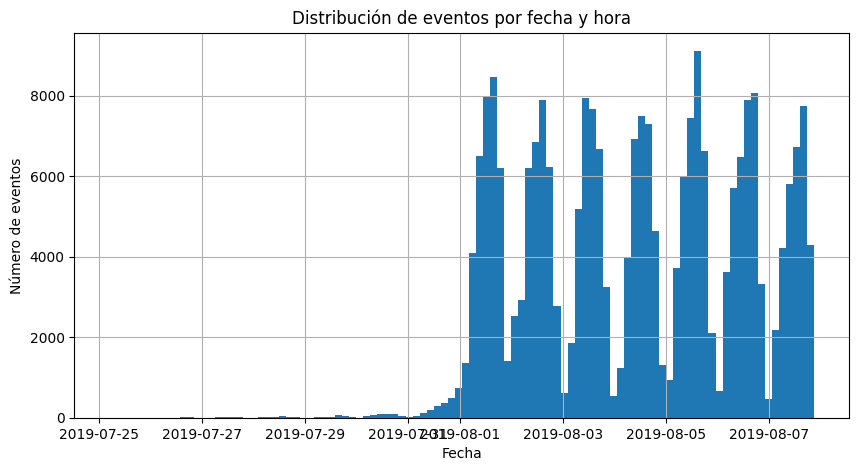

In [9]:
import matplotlib.pyplot as plt

logs['event_datetime'].hist(bins=100, figsize=(10,5))

plt.title('Distribución de eventos por fecha y hora')
plt.xlabel('Fecha')
plt.ylabel('Número de eventos')
plt.show()

**Observaciones:**

El histograma muestra que durante los primeros días del periodo analizado (del 25 al 31 de julio) el número de eventos registrados es significativamente menor. 
A partir del 1 de agosto de 2019 el volumen de eventos aumenta considerablemente y se mantiene relativamente estable durante el resto del periodo.

Esto sugiere que los registros de los primeros días podrían estar incompletos o no representar la actividad real de los usuarios. Para evitar sesgos en el análisis, es recomendable considerar únicamente los datos a partir del momento en que el registro de eventos se vuelve consistente.

In [10]:
logs.groupby('event_date')['event_name'].count()

event_date
2019-07-25        9
2019-07-26       31
2019-07-27       55
2019-07-28      105
2019-07-29      184
2019-07-30      413
2019-07-31     2031
2019-08-01    36229
2019-08-02    35606
2019-08-03    33351
2019-08-04    33033
2019-08-05    36113
2019-08-06    35822
2019-08-07    31144
Name: event_name, dtype: int64

El análisis del número de eventos por día confirma que durante los primeros días del periodo analizado (del 25 al 31 de julio) el volumen de eventos es extremadamente bajo en comparación con el resto del dataset.

A partir del 1 de agosto de 2019 el número de eventos aumenta drásticamente y se mantiene relativamente estable entre 33,000 y 36,000 eventos diarios.

Esto sugiere que los registros anteriores al 1 de agosto probablemente estén incompletos y no reflejen el comportamiento real de los usuarios.

Para evitar sesgos en el análisis del embudo y del experimento A/A/B, se considerarán únicamente los datos a partir del 1 de agosto de 2019.

In [11]:
logs_filtered = logs[logs['event_datetime'] >= '2019-08-01']
logs_filtered.shape

(241298, 6)

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo con el filtro aplicado, de esta forma aseguras no tener "ruido" en tu muestra de datos
</div>

In [12]:
logs['user_id'].nunique(), logs_filtered['user_id'].nunique()

(7551, 7534)

In [13]:
logs.shape[0], logs_filtered.shape[0]

(244126, 241298)

Después de excluir los datos anteriores al 1 de agosto de 2019, el número de eventos pasó de 244,126 a 241,298, lo que implica la eliminación de 2,828 eventos asociados al periodo inicial donde los registros eran incompletos.

En términos de usuarios, el número de usuarios únicos pasó de 7,551 a 7,534, lo que representa una reducción de 17 usuarios.

Dado que la pérdida de datos es mínima en comparación con el tamaño total del dataset, el filtrado no afecta significativamente el análisis y permite trabajar únicamente con el periodo en el que los registros son consistentes.

## Paso 4 — Estudiar el embudo de eventos

In [14]:
logs_filtered['event_name'].value_counts()

MainScreenAppear           117431
OffersScreenAppear          46350
CartScreenAppear            42365
PaymentScreenSuccessful     34113
Tutorial                     1039
Name: event_name, dtype: int64

**Observaciones:**

El evento más frecuente es MainScreenAppear, que representa la pantalla principal de la aplicación y probablemente el punto de entrada al flujo de navegación de los usuarios.

A continuación aparecen eventos relacionados con el proceso de compra, como OffersScreenAppear, CartScreenAppear y PaymentScreenSuccessful, que reflejan las distintas etapas del recorrido del usuario hasta completar un pedido.

El evento Tutorial aparece con una frecuencia mucho menor y probablemente corresponde a usuarios que acceden a una guía inicial de la aplicación. Debido a que no forma parte del flujo principal de compra, no se incluirá en el análisis del embudo.

In [15]:
logs_filtered.groupby('event_name')['user_id'].nunique().sort_values(ascending=False)

event_name
MainScreenAppear           7419
OffersScreenAppear         4593
CartScreenAppear           3734
PaymentScreenSuccessful    3539
Tutorial                    840
Name: user_id, dtype: int64

**Observaciones:**

El evento MainScreenAppear tiene 7419 usuarios, lo cual representa prácticamente todos los usuarios activos en el periodo analizado. Esto confirma que la pantalla principal funciona como el punto de entrada al flujo de navegación.

A partir de ahí, el número de usuarios disminuye progresivamente conforme avanzan en el proceso de compra:

4593 usuarios llegan a OffersScreenAppear, donde visualizan ofertas o productos.

3734 usuarios avanzan hasta CartScreenAppear, lo que indica que revisan o agregan productos al carrito.

3539 usuarios completan el proceso con PaymentScreenSuccessful, es decir, realizan una compra exitosa.

In [16]:
funnel = logs_filtered.groupby('event_name')['user_id'].nunique()

main = funnel['MainScreenAppear']
offers = funnel['OffersScreenAppear']
cart = funnel['CartScreenAppear']
payment = funnel['PaymentScreenSuccessful']

main, offers, cart, payment

offers/main, cart/offers, payment/cart

(0.6190861302062273, 0.8129762682342695, 0.9477771826459561)

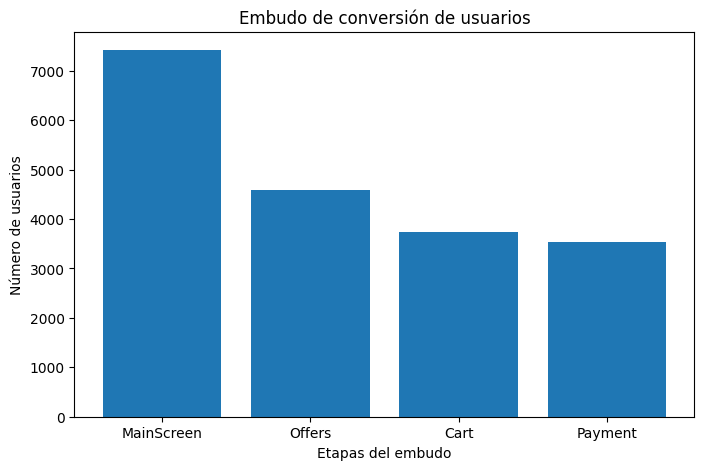

In [17]:


stages = ['MainScreen', 'Offers', 'Cart', 'Payment']
users = [main, offers, cart, payment]

plt.figure(figsize=(8,5))
plt.bar(stages, users)

plt.title('Embudo de conversión de usuarios')
plt.xlabel('Etapas del embudo')
plt.ylabel('Número de usuarios')

plt.show()

**Observaciones:**

El análisis del embudo muestra que **la mayor pérdida de usuarios ocurre entre la pantalla principal y la pantalla de ofertas.** Solo 61.9% de los usuarios que acceden a la pantalla principal continúan explorando productos, lo que indica que una parte importante de los usuarios abandona la navegación en la etapa inicial.

Una vez que los usuarios llegan a la pantalla de ofertas, la conversión mejora considerablemente. El 81.3% de los usuarios que ven ofertas avanzan al carrito, lo que sugiere un alto nivel de interés en los productos mostrados.

Finalmente, la transición del carrito al pago tiene una conversión muy alta (94.8%), lo que indica que la mayoría de los usuarios que agregan productos al carrito terminan completando la compra.

En total, **aproximadamente 47.7% de los usuarios completan todo el recorrido** desde la pantalla principal hasta el pago exitoso.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien hecho los cálculos de las conversiones! Al tratarse de una prueba AB puedes dejarlo en una visualización donde se observe cada grupo ayuda para que la comparación sea más visual y fácil de exponer
</div>

## Paso 5. Estudiar los resultados del experimento


In [18]:
logs_filtered.groupby('exp_id')['user_id'].nunique()

exp_id
246    2484
247    2513
248    2537
Name: user_id, dtype: int64

**Se muestran las siguientes cantidades de usuarios en cada grupo:**

- Grupo 246: 2484 usuarios

- Grupo 247: 2513 usuarios

- Grupo 248: 2537 usuarios

Esta distribución relativamente equilibrada permite continuar con el análisis del experimento sin riesgo de sesgos importantes derivados de tamaños de muestra muy diferentes.

In [19]:
from scipy import stats
import numpy as np

event = 'MainScreenAppear'

users_event = (
    logs_filtered[logs_filtered['event_name'] == event]
    .groupby('exp_id')['user_id']
    .nunique()
)

users_total = logs_filtered.groupby('exp_id')['user_id'].nunique()

In [20]:
successes = np.array([
    users_event[246],
    users_event[247]
])

trials = np.array([
    users_total[246],
    users_total[247]
])

p1 = successes[0] / trials[0]
p2 = successes[1] / trials[1]

p_combined = (successes.sum()) / (trials.sum())

difference = p1 - p2

z_value = difference / np.sqrt(
    p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1])
)

p_value = (1 - stats.norm.cdf(abs(z_value))) * 2

p_value

0.7570597232046099

Se realizó una prueba A/A comparando los grupos de control 246 y 247 con el objetivo de verificar si existían diferencias significativas entre ellos.

El resultado de la prueba estadística arrojó un p-value de 0.757, que es considerablemente mayor que el nivel de significancia establecido (α = 0.05).

Por lo tanto, no se rechaza la hipótesis nula, lo que indica que **no existe una diferencia estadísticamente significativa entre los grupos de control.**

Este resultado sugiere que la asignación de usuarios a los grupos experimentales fue adecuada y que el experimento se encuentra correctamente configurado para continuar con el análisis.

In [21]:
main_event = logs_filtered[logs_filtered['event_name'] == 'MainScreenAppear']

users_main = main_event.groupby('exp_id')['user_id'].nunique()

total_users = logs_filtered.groupby('exp_id')['user_id'].nunique()

proportions = users_main / total_users

users_main, proportions

(exp_id
 246    2450
 247    2476
 248    2493
 Name: user_id, dtype: int64,
 exp_id
 246    0.986312
 247    0.985277
 248    0.982657
 Name: user_id, dtype: float64)

In [22]:
def z_test(event_name, group1, group2):
    
    event_users = (
        logs_filtered[logs_filtered['event_name'] == event_name]
        .groupby('exp_id')['user_id']
        .nunique()
    )
    
    successes = np.array([
        event_users[group1],
        event_users[group2]
    ])
    
    trials = np.array([
        total_users[group1],
        total_users[group2]
    ])
    
    p1 = successes[0] / trials[0]
    p2 = successes[1] / trials[1]
    
    p_combined = successes.sum() / trials.sum()
    
    difference = p1 - p2
    
    z_value = difference / np.sqrt(
        p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1])
    )
    
    p_value = (1 - stats.norm.cdf(abs(z_value))) * 2
    
    print(event_name, "p-value:", p_value)
    
   

In [23]:
events = logs_filtered['event_name'].unique()

for event in events:
    z_test(event, 246, 247)

Tutorial p-value: 0.9376996189257114
MainScreenAppear p-value: 0.7570597232046099
OffersScreenAppear p-value: 0.2480954578522181
CartScreenAppear p-value: 0.22883372237997213
PaymentScreenSuccessful p-value: 0.11456679313141849


**Observaciones: grupo 246 vs 247**

Se realizó una prueba A/A comparando los grupos de control 246 y 247 para todos los eventos registrados en la aplicación.

Los resultados muestran que en todos los casos los p-values son mayores que el nivel de significancia establecido (α = 0.05).

Esto indica que no existen diferencias estadísticamente significativas entre los dos grupos de control, lo que sugiere que la asignación de usuarios a los grupos experimentales fue realizada correctamente.

Por lo tanto, se puede confiar en la validez del experimento y continuar con el análisis comparando el grupo experimental con los grupos de control.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien! Siempre es bueno aplicar pruebas estadísticas a cada etapa del embudo para entender si en alguna parte el comportamiento de los usuarios ha cambiado 
</div>

In [24]:
for event in events:
    z_test(event, 246, 248)

Tutorial p-value: 0.8264294010087645
MainScreenAppear p-value: 0.2949721933554552
OffersScreenAppear p-value: 0.20836205402738917
CartScreenAppear p-value: 0.07842923237520116
PaymentScreenSuccessful p-value: 0.2122553275697796


**Observaciones: grupo 246 vs 248**


Se comparó el grupo de control 246 con el grupo experimental 248, que utilizaba la nueva tipografía en la aplicación.

Para todos los eventos analizados, los p-values obtenidos fueron mayores que el nivel de significancia establecido (α = 0.05).

Esto indica que no se detectaron diferencias estadísticamente significativas en el comportamiento de los usuarios entre ambos grupos.

Por lo tanto, no existe evidencia de que el cambio de tipografía haya afectado negativamente la interacción de los usuarios con la aplicación.

In [25]:
for event in events:
    z_test(event, 247, 248)

Tutorial p-value: 0.765323922474501
MainScreenAppear p-value: 0.4587053616621515
OffersScreenAppear p-value: 0.9197817830592261
CartScreenAppear p-value: 0.5786197879539783
PaymentScreenSuccessful p-value: 0.7373415053803964


**Observaciones: grupo 247 vs 248**

También se comparó el grupo experimental 248 con el segundo grupo de control 247.

En todos los eventos analizados los p-values obtenidos fueron mayores que el nivel de significancia establecido (α = 0.05), lo que indica que no existen diferencias estadísticamente significativas entre ambos grupos.

Este resultado coincide con la comparación anterior entre el grupo de control 246 y el grupo experimental 248.

En conjunto, estos resultados sugieren que el cambio de tipografía no tuvo un impacto significativo en el comportamiento de los usuarios dentro de la aplicación.

In [26]:
def z_test_combined(event_name):
    
    event_users = (
        logs_filtered[logs_filtered['event_name'] == event_name]
        .groupby('exp_id')['user_id']
        .nunique()
    )
    
    total_users = logs_filtered.groupby('exp_id')['user_id'].nunique()
    
    successes = np.array([
        event_users[246] + event_users[247],
        event_users[248]
    ])
    
    trials = np.array([
        total_users[246] + total_users[247],
        total_users[248]
    ])
    
    p1 = successes[0] / trials[0]
    p2 = successes[1] / trials[1]
    
    p_combined = successes.sum() / trials.sum()
    
    difference = p1 - p2
    
    z_value = difference / np.sqrt(
        p_combined * (1 - p_combined) * (1/trials[0] + 1/trials[1])
    )
    
    p_value = (1 - stats.norm.cdf(abs(z_value))) * 2
    
    print(event_name, "p-value:", p_value)

In [27]:
for event in events:
    z_test_combined(event)

Tutorial p-value: 0.764862472531507
MainScreenAppear p-value: 0.29424526837179577
OffersScreenAppear p-value: 0.43425549655188256
CartScreenAppear p-value: 0.18175875284404386
PaymentScreenSuccessful p-value: 0.6004294282308704


## Análisis final

Por último, se comparó el grupo experimental 248 con los grupos de control combinados (246 + 247) para aumentar el tamaño de muestra del grupo de referencia y obtener una comparación más robusta.

Los resultados muestran que todos los p-values obtenidos son mayores que el nivel de significancia establecido (α = 0.05). Esto indica que no existen diferencias estadísticamente significativas entre el grupo experimental y el grupo de control combinado para ninguno de los eventos analizados.

Durante el análisis se realizaron múltiples pruebas estadísticas, evaluando cinco eventos diferentes en cuatro comparaciones entre grupos experimentales, lo que resulta en 20 pruebas de hipótesis en total. Cuando se realizan múltiples pruebas, aumenta la probabilidad de obtener resultados falsos positivos. Para controlar este riesgo se puede aplicar una corrección por comparaciones múltiples, como la corrección de *Bonferroni*, que consiste en dividir el nivel de significancia entre el número total de pruebas realizadas.

En este caso:

0.05
/
20
=
0.0025
0.05/20= 0.0025

Por lo tanto, el nivel de significancia ajustado sería 0.0025. Sin embargo, dado que todos los p-values obtenidos en el análisis son considerablemente mayores incluso que este nivel ajustado, las conclusiones del experimento se mantienen sin cambios.

En conjunto, los resultados del experimento sugieren que el cambio de tipografía no tiene un impacto significativo en el comportamiento de los usuarios dentro de la aplicación. Los usuarios continúan navegando, interactuando con las ofertas y completando el proceso de compra de manera similar independientemente del diseño de fuente utilizado.

Adicionalmente, el análisis del embudo de eventos mostró que la mayor pérdida de usuarios ocurre en la transición entre la pantalla principal y la visualización de ofertas. Sin embargo, una vez que los usuarios avanzan en el proceso de compra, la tasa de conversión aumenta considerablemente, especialmente en las etapas finales del carrito y el pago.

En conclusión, la implementación de la nueva tipografía puede realizarse sin riesgo significativo para la experiencia del usuario o las métricas de conversión, ya que no se detectaron cambios estadísticamente significativos en el comportamiento de los usuarios durante el experimento.

<div class="alert alert-block alert-success">
<b>Comentario general (1ra Iteracion)</b> <a class=“tocSkip”></a>

Buen trabajo con el proyecto, te felicito! Realizaste un muy buen análisis de los grupos de tratamiento entre los cambios obtenidos entre uno y otro respecto al funnel que el usuario debe seguir, las conclusiones te recomiendo hacerlo un poco más detallado, especialmente al final del proyecto donde se debería resumir los hallazgos más importantes de todo el proyecto y no sólo la parte final. 
    
No cabe duda que vas por excelente camino para convertirte en Data Analyst, saludos!
</div>